# Demo: the Bayesian workflow for a ball drop with drag

A ball is released from rest and falls under gravity against a drag force linear in
the velocity,

$$
m\dot v = mg - b v
\qquad\Longrightarrow\qquad
v(t) = v_t\left(1 - e^{-t/\tau}\right),
\qquad
x(t) = v_t t - v_t\tau\left(1 - e^{-t/\tau}\right),
$$

with **terminal velocity** $v_t = mg/b$ and **relaxation time** $\tau = m/b$. We
measure the distance fallen $x(t)$ and infer the parameters.

> **Two parameters, not three**
>
> $v_t$, $\tau$ and $g$ are not independent: $v_t = g\tau$, so $b/m = 1/\tau = g/v_t$.
> If $g$ is known, terminal velocity and $b/m$ are *the same parameter*. Here we do
> **not** assume $g$: we infer $(g, \tau)$ and treat $v_t = g\tau$ as a derived
> quantity. 

The unknowns are $\boldsymbol{\theta} = (g, \tau, \sigma_\epsilon)$, with $\sigma_\epsilon$ the measurement
noise on $x$.

**A note on the data.** Real drag on a ball at these speeds is *quadratic*, not
linear — at $v_t \approx 9.5$ m/s a table-tennis ball has
$\mathrm{Re} \approx 2.5\times 10^{4}$, far outside the Stokes regime where
$f \propto v$ holds. We nevertheless simulate the first data set from the linear
model above, so that steps 1–5 run in a world where the model is exactly right and
every result can be checked against a known answer. Section 7 then generates data
from quadratic drag, changes nothing else, and watches the analysis fail.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
import emcee
import corner

INK, INK_SOFT, INK_MUTED, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#fcfcfb"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
FILL1, FILL2 = "#cde2fb", "#fbdcd0"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": INK_MUTED, "axes.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.labelcolor": INK, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "cm", "font.size": 11,
})

rng = np.random.default_rng(2026)

## 1. The statistical model

A light ball — think table tennis — has $v_t \approx 9.5$ m/s and therefore
$\tau = v_t/g \approx 0.97$ s. We track it for $T = 2$ s (about 11 m of fall) with
a camera good to $\sigma_\epsilon = 1$ cm.

In [2]:
G_TRUE, VT_TRUE = 9.81, 9.5
TAU_TRUE = VT_TRUE / G_TRUE
SIGMA_TRUE = 0.01                 # metres
ND, T_OBS = 40, 2.0

t_data = np.linspace(T_OBS / ND, T_OBS, ND)


def distance(t, g, tau):
    "Distance fallen from rest with linear drag.  v_t = g*tau."
    t = np.asarray(t, dtype=float)
    return g * tau * t - g * tau**2 * (1.0 - np.exp(-t / tau))


def generate(t, g, tau, sigma, rng):
    "One draw from the statistical model."
    return distance(t, g, tau) + rng.normal(0.0, sigma, size=np.size(t))


x_data = generate(t_data, G_TRUE, TAU_TRUE, SIGMA_TRUE, rng)
# smooth time grid for plotting only
tg = np.linspace(0.0, 4.2, 400)

print(f"v_t = {VT_TRUE} m/s   tau = {TAU_TRUE:.3f} s   T/tau = {T_OBS / TAU_TRUE:.2f}")
print(f"fall in {T_OBS} s: {distance(T_OBS, G_TRUE, TAU_TRUE):.2f} m  "
      f"(free fall would be {0.5 * G_TRUE * T_OBS**2:.2f} m)")

v_t = 9.5 m/s   tau = 0.968 s   T/tau = 2.07
fall in 2.0 s: 10.97 m  (free fall would be 19.62 m)


## 2. Priors — and what they imply for things you care about

All three parameters are positive, with magnitudes unknown to within orders of magnitude. Strictly only 
$\sigma_\epsilon$ is a scale parameter. What justifies a flat-in-log prior for all three is the weaker requirement that the inference should not depend on whether we measure time in seconds or milliseconds.

Three candidate priors:

| | $g$ or $v_t = g\tau$ | $\tau$ | $\sigma_\epsilon$ |
|---|---|---|---|
| **A** (uniform) | $p(v_t) = \mathcal{U}(1, 30)$ m/s | $\mathcal{U}(0.1, 5)$ s | $\mathcal{U}(0, 1)$ m |
| **B** (log-uniform) | $p(g) \propto 1/g$ on $[1, 100]$ m/s$^2$ | $\propto 1/\tau$ on $[0.05, 20]$ s | $\propto 1/\sigma_\epsilon$ on $[10^{-4}, 1]$ m |
| **C** (log-normal) | $\ln v_t \sim \mathcal{N}(\ln 10,\, \ln 2)$ | $\ln \tau \sim \mathcal{N}(0,\, \ln 2)$ | as B |

Each prior fixes exactly one of the first pair; the other follows from $v_t = g\tau$.
Prior A is stated for $(v_t, \tau)$ — the parametrization that might look natural.

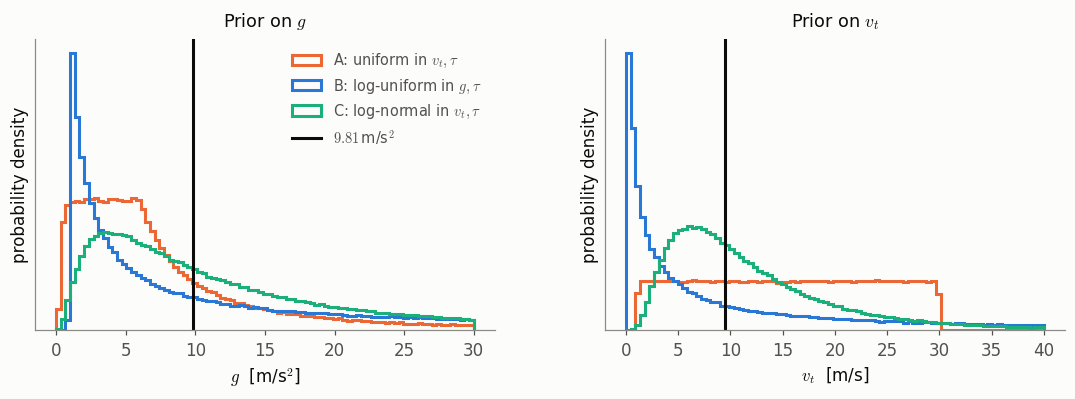

                           A         B         C
median g               6.073    10.048    10.002
P(5 < g < 15)          0.404     0.238     0.420
P(g > 30)              0.085     0.262     0.131


In [3]:
n = 400_000
r = np.random.default_rng(4)

# A: uniform in the parameters it states
vt_A = r.uniform(1.0, 30.0, n); tau_A = r.uniform(0.1, 5.0, n)
g_A = vt_A / tau_A                                        # induced

# B: log-uniform (flat in log g, log tau)
g_B = np.exp(r.uniform(np.log(1.0), np.log(100.0), n))
tau_B = np.exp(r.uniform(np.log(0.05), np.log(20.0), n))
vt_B = g_B * tau_B                                        # induced

# C: weakly informative about the *ball* -- v_t near 10 m/s and tau near 1 s,
#    each uncertain by a factor of two.  g = v_t/tau is then induced.
vt_C = 10.0 * np.exp(r.normal(0.0, np.log(2.0), n))
tau_C = 1.0 * np.exp(r.normal(0.0, np.log(2.0), n))
g_C = vt_C / tau_C                                        # induced


def density(ax, x, edges, color, label=None):
    "Density inside the window, correct even when mass falls outside it."
    w = np.full(len(x), 1.0 / (len(x) * (edges[1] - edges[0])))
    ax.hist(x, bins=edges, weights=w, histtype="step", lw=2, color=color, label=label)


fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9),
                         gridspec_kw=dict(wspace=0.24, left=0.08, right=0.98,
                                          top=0.85, bottom=0.17))
eg = np.linspace(0, 30, 90)
density(axes[0], g_A, eg, C2, r"A: uniform in $v_t,\tau$")
density(axes[0], g_B, eg, C1, r"B: log-uniform in $g,\tau$")
density(axes[0], g_C, eg, C3, r"C: log-normal in $v_t,\tau$")
axes[0].axvline(G_TRUE, color=INK, lw=2, label=r"$9.81\,$m/s$^2$")
axes[0].set_xlabel(r"$g$  [m/s$^2$]")
axes[0].set_title("Prior on $g$", fontsize=11.5, pad=8)
axes[0].legend(frameon=False, fontsize=9.5, labelcolor=INK_SOFT)

ev = np.linspace(0, 40, 90)
density(axes[1], vt_A, ev, C2)
density(axes[1], vt_B, ev, C1)
density(axes[1], vt_C, ev, C3)
axes[1].axvline(VT_TRUE, color=INK, lw=2)
axes[1].set_xlabel(r"$v_t$  [m/s]")
axes[1].set_title("Prior on $v_t$", fontsize=11.5, pad=8)

for ax in axes:
    ax.set_ylabel("probability density")
    ax.set_yticks([])
plt.show()

print(f"{'':18}{'A':>10}{'B':>10}{'C':>10}")
for lab, f in (("median g", np.median),
               ("P(5 < g < 15)", lambda g: np.mean((g > 5) & (g < 15))),
               ("P(g > 30)", lambda g: np.mean(g > 30))):
    print(f"{lab:18}{f(g_A):10.3f}{f(g_B):10.3f}{f(g_C):10.3f}")

All three are far wider than the data will turn out to be, but they are not the
same kind of wide. **A** and **B** are *diffuse*: they spread belief over ranges
nobody would defend, and differ mainly in how they spread it. **C** is *weakly
informative* — it carries the order of magnitude we genuinely know, and little
else. None of them is informative at the resolution this experiment reaches: prior
C puts $g$ somewhere between about $4$ and $27$ m/s$^2$, while the posterior will
place it between $9.79$ and $9.82$. So the check ahead does not tell us which prior
is right. It tells us what each one says without meaning to.

**A** is uniform in what it states, but the induced prior on $g$ is a ratio
distribution nobody chose: median $6.1$ m/s$^2$, with a tail past $70$.

**B** spreads $g$ evenly over two decades. That is honest ignorance if we have
none — but we do have some, and B pays for its flatness: $P(5 < g < 15) = 0.24$
against $0.40$ for A, and a quarter of its mass sits above $30$ m/s$^2$.
Flat-in-log is not automatically the safer choice; it moves the arbitrariness into
the bounds.

**C** says what we actually believe about the ball — $v_t$ near $10$ m/s and $\tau$
near $1$ s, each good to a factor of two. Since a ratio of log-normals is
log-normal, the induced prior on $g$ is log-normal too, centred near $10$ with a
factor $\sim\!2.7$ spread. Note that we never asserted $g \approx 9.8$: it followed
from beliefs about the ball, which is why the inferred $g$ is still a real check.

That is also the deeper point. $g$, $\tau$ and $v_t$ are tied by $v_t = g\tau$, so a
prior on any two fixes the third. There is no way to be informative about $g$
and agnostic about the ball velocity at the same time.

> **Prior checking**
>
> Pushing the prior forward onto a quantity you care about is the cheapest useful
> thing in the whole workflow, and the step most often skipped. It does not tell you
> which prior to use — it tells you what you have accidentally assumed.

**We adopt C for the rest of the notebook** — if one of them is defensible, use it.
It costs nothing here: with $40$ measurements at $1$ cm the likelihood is sharp
enough that all three give the same posterior to every digit we quote, and swapping
B for C moves $g$ by $0.0002$ m/s$^2$ against a posterior width of $0.016$. Prior
choice bites when the data are weak, which is exactly when it tends to go
unexamined.

### Prior predictive check

Draw parameters from priors B and C, run them through the generating recipe, and see what
trajectories the model considers possible before any data is used.

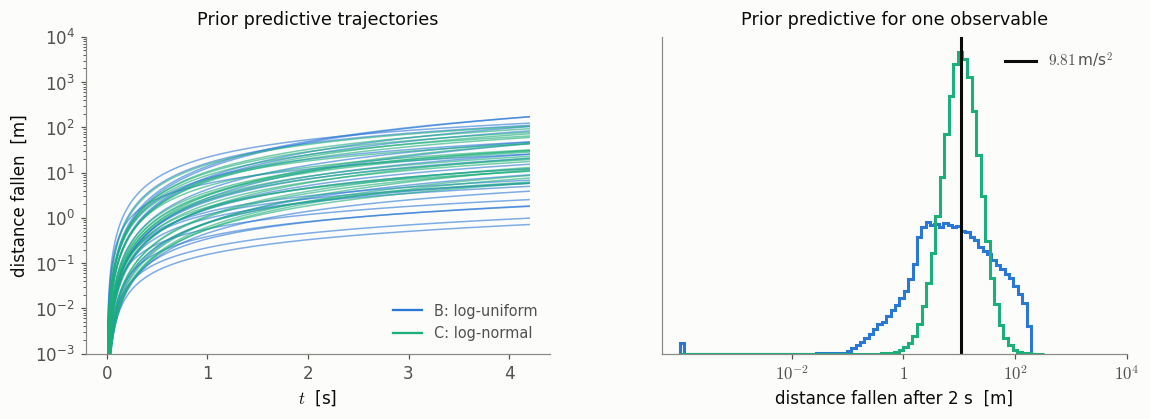

In [4]:
LOG_SIG = np.log(2.0)              # prior C: a factor of two, one sigma


def sample_prior(n, rng, kind="C"):
    "Draw (g, tau, sigma) from prior B (log-uniform) or prior C (log-normal)."
    sig = np.exp(rng.uniform(np.log(1e-4), np.log(1.0), n))      # same in both
    if kind == "B":
        g = np.exp(rng.uniform(np.log(1.0), np.log(100.0), n))
        tau = np.exp(rng.uniform(np.log(0.05), np.log(20.0), n))
    else:
        vt = 10.0 * np.exp(rng.normal(0.0, LOG_SIG, n))
        tau = 1.0 * np.exp(rng.normal(0.0, LOG_SIG, n))
        g = vt / tau
    return np.column_stack([g, tau, sig])


fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0),
                         gridspec_kw=dict(wspace=0.24, left=0.07, right=0.98,
                                          top=0.86, bottom=0.14))
for kind, col in (("B", C1), ("C", C3)):
    for g, tau, sig in sample_prior(25, np.random.default_rng(8), kind):
        axes[0].plot(tg, distance(tg, g, tau), color=col, lw=1.0, alpha=0.6)
axes[0].plot([], [], color=C1, lw=1.5, label="B: log-uniform")
axes[0].plot([], [], color=C3, lw=1.5, label="C: log-normal")
axes[0].legend(frameon=False, fontsize=9.5, labelcolor=INK_SOFT, loc="lower right")
#axes[0].plot(t_data, x_data, "o", ms=3.5, color=INK, zorder=5)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-3, 1e4)
axes[0].set_ylabel("distance fallen  [m]")
axes[0].set_title("Prior predictive trajectories", fontsize=11.5, pad=8)

# a statistic with a physical meaning: how far has it fallen after 2 s?
falls = {}
for kind, col in (("B", C1), ("C", C3)):
    d = sample_prior(200_000, np.random.default_rng(9), kind)
    falls[kind] = distance(T_OBS, d[:, 0], d[:, 1]) + np.random.default_rng(
        10).normal(0, 1, len(d)) * d[:, 2]
    axes[1].hist(np.log10(np.clip(falls[kind], 1e-4, None)), bins=80, density=True,
                 histtype="step", lw=2, color=col)
axes[1].axvline(np.log10(distance(T_OBS, G_TRUE, TAU_TRUE)), color=INK, lw=2,
                label=r"$9.81\,$m/s$^2$")
axes[1].set_xticks([-2, 0, 2, 4], ["$10^{-2}$", "$1$", "$10^{2}$", "$10^{4}$"])
axes[1].set_xlabel(r"distance fallen after 2 s  [m]")
axes[1].set_yticks([])
axes[1].legend(frameon=False, fontsize=10, labelcolor=INK_SOFT)
axes[1].set_title("Prior predictive for one observable", fontsize=11.5, pad=8)
axes[0].set_xlabel("$t$  [s]")
plt.show()

# where the observation falls in each prior predictive -- commented out so that
# the data stay unseen until section 3
# for kind in ("B", "C"):
#     pct = 100 * np.mean(falls[kind] < x_data[-1])
#     print(f"prior {kind}: observed fall after 2 s ({x_data[-1]:.2f} m) sits at the "
#           f"{pct:4.0f}-th percentile of the prior predictive")

B admits everything from a ball that barely moves to one that falls a kilometre;
C keeps to more realistic trajectories. Both contain the observed data
comfortably — at the $57$th and $51$st percentile of the predicted fall after 2 s —
so neither is in conflict with it. A prior predictive that *excluded* the data would
be the alarm; one that is merely far too wide, like B, is a warning that the prior
is doing no work.

## 3. The data and the likelihood

The data below are simulated from the
linear-drag model itself — the deliberately idealised case; the realistic
quadratic one arrives later.

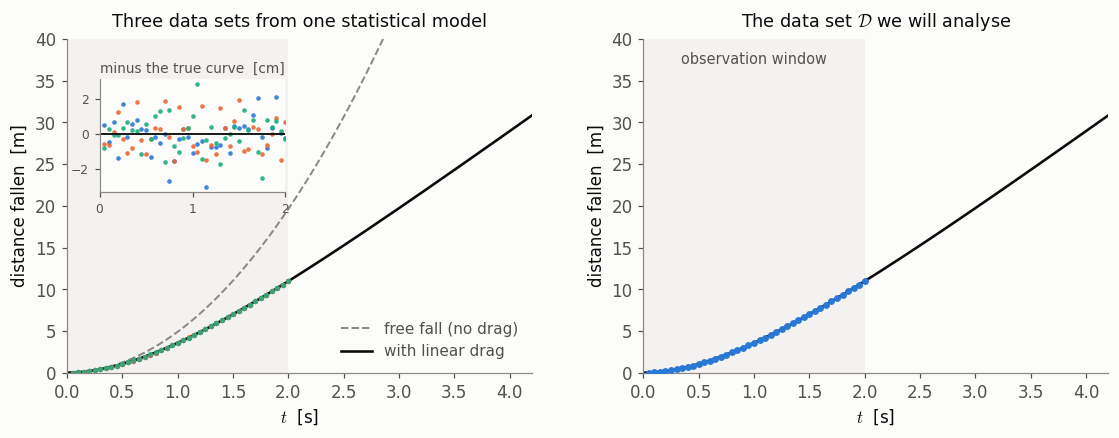

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.1),
                         gridspec_kw=dict(wspace=0.24, left=0.07, right=0.98,
                                          top=0.88, bottom=0.14))

reps = [generate(t_data, G_TRUE, TAU_TRUE, SIGMA_TRUE, np.random.default_rng(50 + k))
        for k in range(3)]
cols = [C1, C2, C3]

axes[0].plot(tg, 0.5 * G_TRUE * tg**2, color=INK_MUTED, lw=1.3, ls="--",
             label="free fall (no drag)")
axes[0].plot(tg, distance(tg, G_TRUE, TAU_TRUE), color=INK, lw=1.7,
             label="with linear drag")
for xk, col in zip(reps, cols):
    axes[0].plot(t_data, xk, "o", ms=3.5, mfc=col, mec="none", alpha=0.8)
axes[0].legend(frameon=False, fontsize=10, labelcolor=INK_SOFT, loc="lower right")
axes[0].set_title("Three data sets from one statistical model", fontsize=11.5, pad=8)

# 1 cm of noise on an 11 m fall is invisible above, so the three sets lie on top of
# one another: subtract the true curve to see that they really are different draws
ins = axes[0].inset_axes([0.07, 0.54, 0.40, 0.34])
for xk, col in zip(reps, cols):
    ins.plot(t_data, 100 * (xk - distance(t_data, G_TRUE, TAU_TRUE)), "o", ms=3,
             mfc=col, mec="none", alpha=0.9)
ins.axhline(0.0, color=INK, lw=1.2)
ins.set_title("minus the true curve  [cm]", fontsize=9, color=INK_SOFT, pad=4)
ins.tick_params(labelsize=8)
ins.set_xlim(0, T_OBS)
ins.set_xticks([0, 1, 2])
ins.set_yticks([-2, 0, 2])

axes[1].errorbar(t_data, x_data, yerr=SIGMA_TRUE, fmt="o", ms=3.5, color=C1,
                 ecolor=C1, elinewidth=1, capsize=0, zorder=4)
axes[1].plot(tg, distance(tg, G_TRUE, TAU_TRUE), color=INK, lw=1.7)
axes[1].set_title(r"The data set $\mathcal{D}$ we will analyse", fontsize=11.5, pad=8)

for ax in axes:
    ax.axvspan(0, T_OBS, color=INK_MUTED, alpha=0.08, lw=0)
    ax.set_xlabel("$t$  [s]")
    ax.set_ylabel("distance fallen  [m]")
    ax.set_xlim(0, tg[-1])
    ax.set_ylim(0, 40)
axes[1].text(T_OBS / 2, 37, "observation window", ha="center", fontsize=9.5,
             color=INK_SOFT)
plt.show()

### The likelihood

The statistical model of section 1 says $x_i = x(t_i; g,\tau) + \epsilon_i$ with
$\epsilon_i \sim \mathcal{N}(0, \sigma_\epsilon^2)$, independently for each frame.
A single measurement therefore has

$$
p(x_i \mid g,\tau,\sigma_\epsilon, I) = \frac{1}{\sqrt{2\pi}\,\sigma_\epsilon}
  \exp\left[-\frac{\bigl(x_i - x(t_i; g,\tau)\bigr)^2}{2\sigma_\epsilon^2}\right],
$$

Independence turns the joint density into a product over the $N_d$ frames:

$$
p(\mathcal{D} \mid g,\tau,\sigma_\epsilon, I)
 = \prod_{i=1}^{N_d} p(x_i \mid g,\tau,\sigma_\epsilon, I)
 = \left(\frac{1}{2\pi\sigma_\epsilon^2}\right)^{N_d/2}
   \exp\left[-\frac{1}{2\sigma_\epsilon^2}
     \sum_{i=1}^{N_d}\bigl(x_i - x(t_i; g,\tau)\bigr)^2\right],
$$

and taking the logarithm turns the product into a sum:

$$
\ln p(\mathcal{D} \mid g,\tau,\sigma_\epsilon, I) =
 -N_d \ln \sigma_\epsilon
 - \frac{1}{2\sigma_\epsilon^2}\sum_{i} \bigl[x_i - x(t_i; g,\tau)\bigr]^2
 + \text{const}.
$$

Read as a function of the parameters with the data held fixed, this is the quantity
the sampler evaluates. Note that $x(t; g,\tau)$ is a non-linear function of the parameters.

## 4. The posterior

Bayes' theorem combines the likelihood of section 3 with the prior of section 2:

$$
p(g,\tau,\sigma_\epsilon \mid \mathcal{D}, I) \;\propto\;
  p(\mathcal{D} \mid g,\tau,\sigma_\epsilon, I)\;
  p(g,\tau,\sigma_\epsilon \mid I).
$$

There is no analytic posterior: $x(t;g,\tau)$ is
nonlinear in both parameters. We sample with `emcee` (a black box here) working in $\ln g$, $\ln\tau$, $\ln\sigma_\epsilon$, which is
where prior C is Gaussian and the prior on $\sigma_\epsilon$ is flat.

The walkers start from the posterior mode, located by an optimiser that itself
starts from a draw of the prior — no use is made of the true parameters. Where
a chain starts cannot change the distribution it samples, only whether it gets
there in finite time.


In [6]:
# The log-uniform prior on sigma is improper without bounds, so these are part of
# the prior, not a numerical guard.  g and tau need none: prior C is proper.
SIGMA_BOUNDS = (1e-4, 1.0)


def log_prior_C(log_g, log_tau):
    """Prior C on (g, tau), in the sampling variables.

    C states log-normal priors on the *ball velocity*: ln v_t ~ N(ln 10, ln 2) and
    ln tau ~ N(0, ln 2).  We sample in (ln g, ln tau), and ln v_t = ln g + ln tau
    with unit Jacobian, so the prior is just those two Gaussians.
    """
    return (-0.5 * ((log_g + log_tau - np.log(10.0)) / LOG_SIG) ** 2
            - 0.5 * (log_tau / LOG_SIG) ** 2)


def log_prior(log_theta):
    "The whole prior.  sigma is flat in log sigma, between its bounds."
    if not SIGMA_BOUNDS[0] < np.exp(log_theta[2]) < SIGMA_BOUNDS[1]:
        return -np.inf
    return log_prior_C(log_theta[0], log_theta[1])


def log_likelihood(log_theta, t, x):
    g, tau, sigma = np.exp(log_theta)
    r = x - distance(t, g, tau)
    return -len(x) * np.log(sigma) - 0.5 * r @ r / sigma**2


def log_posterior(log_theta, t, x):
    lp = log_prior(log_theta)
    # skip the likelihood where the prior already rejects: it can return nan there
    return lp if not np.isfinite(lp) else lp + log_likelihood(log_theta, t, x)


def fit_mode(t, x, rng):
    """Posterior mode, located by an optimiser started from a prior draw.

    No knowledge of the true parameters is used.  Starting the walkers here is a
    matter of efficiency only -- it cannot change the distribution being sampled,
    but it does decide whether we reach it in a finite chain.  Walkers drawn
    straight from the prior do not: the posterior is some two orders of magnitude
    narrower than the prior and lies along a thin ridge, so part of the ensemble
    strands in the outfield and every estimate comes out too wide.
    """
    log_theta0 = np.log(sample_prior(1, rng)[0])
    res = minimize(lambda th: -log_posterior(th, t, x), log_theta0,
                   method="Nelder-Mead",
                   options=dict(maxiter=20000, maxfev=20000, xatol=1e-10, fatol=1e-10))
    return res.x


def run_mcmc(t, x, nwalkers=32, nsteps=12000, nburn=3000, thin=15, seed=0):
    r = np.random.default_rng(seed)
    p0 = fit_mode(t, x, r) + r.normal(0, 0.01, size=(nwalkers, 3))
    np.random.seed(seed)          # emcee draws from numpy's global RNG
    sampler = emcee.EnsembleSampler(nwalkers, 3, log_posterior, args=(t, x))
    sampler.run_mcmc(p0, nsteps, progress=False)
    return np.exp(sampler.get_chain(discard=nburn, thin=thin, flat=True)), sampler


chain, sampler = run_mcmc(t_data, x_data, seed=42)
v_t_chain = chain[:, 0] * chain[:, 1]
print(f"{chain.shape[0]} samples, acceptance {sampler.acceptance_fraction.mean():.2f}, "
      f"autocorrelation time ~ {sampler.get_autocorr_time(quiet=True).mean():.0f} steps")
for nm, v, truth in (("g      ", chain[:, 0], G_TRUE), ("tau    ", chain[:, 1], TAU_TRUE),
                     ("sigma  ", chain[:, 2], SIGMA_TRUE),
                     ("v_t    ", v_t_chain, VT_TRUE)):
    print(f"  {nm} {v.mean():8.4f} +- {v.std():7.4f}   (true {truth:.4f})")

19200 samples, acceptance 0.65, autocorrelation time ~ 38 steps
  g         9.8062 +-  0.0163   (true 9.8100)
  tau       0.9698 +-  0.0038   (true 0.9684)
  sigma     0.0085 +-  0.0010   (true 0.0100)
  v_t       9.5103 +-  0.0217   (true 9.5000)


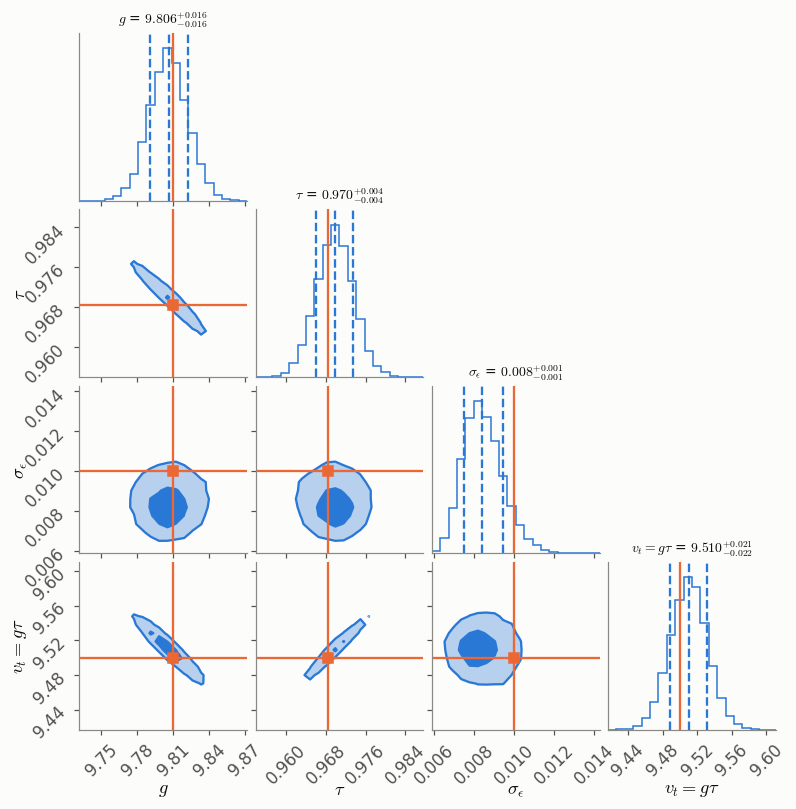

In [7]:
fig = corner.corner(np.column_stack([chain, v_t_chain]),
                    labels=["$g$", r"$\tau$", r"$\sigma_\epsilon$", "$v_t = g\\tau$"],
                    truths=[G_TRUE, TAU_TRUE, SIGMA_TRUE, VT_TRUE],
                    truth_color=C2, color=C1, show_titles=True, title_fmt=".3f",
                    title_kwargs=dict(fontsize=9), label_kwargs=dict(fontsize=12),
                    quantiles=[0.16, 0.5, 0.84], plot_datapoints=False,
                    fill_contours=True, levels=(0.393, 0.865))
fig.set_size_inches(7.4, 7.4)
plt.show()

$g$ and $\tau$ are strongly anti-correlated ($\rho \approx -0.99$): the data pin
down the $t^2$ coefficient $g$ far better than the small $t^3$ correction that
carries $\tau$. The derived $v_t = g\tau$ is far better determined than either —
the data constrain the *combination* that controls the late-time motion.

### Checking the sampler

With a Jeffreys prior we can do the $\sigma_\epsilon$ integral analytically — the same
trick as for the Gaussian mean-and-variance problem:

$$
p(g,\tau \mid \mathcal{D}, I) \;\propto\; \int_0^\infty \frac{d\sigma_\epsilon}{\sigma_\epsilon^{N_d+1}}
  e^{-\mathrm{RSS}/2\sigma_\epsilon^2} \;\propto\; \mathrm{RSS}(g,\tau)^{-N_d/2},
$$

and multiplying by prior C leaves the two-dimensional marginal posterior, which can
be evaluated exactly on a grid and compared with the chain. With only two parameters left, this is cheap — and it is a
better check than an analytic formula, because it is the *actual* posterior.

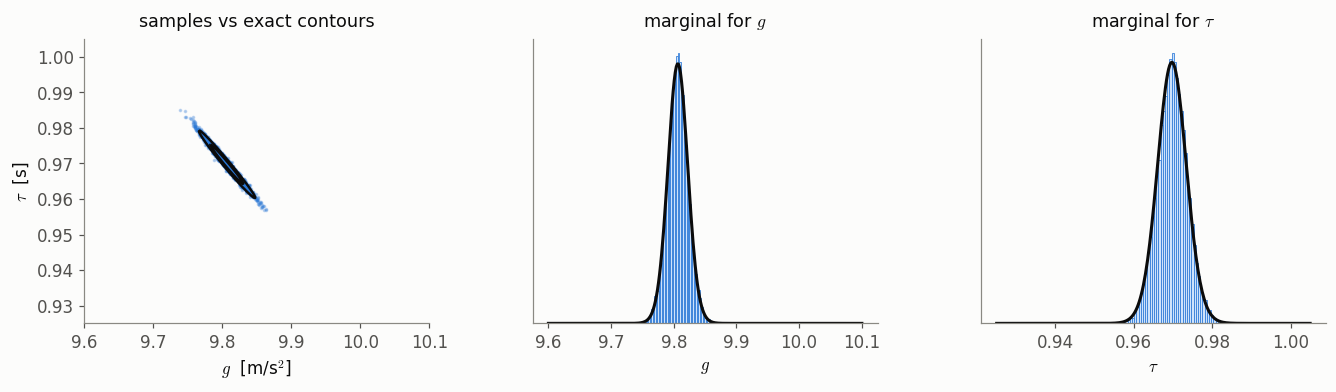

  g     grid:   9.80649 +- 0.01629    MCMC:   9.80619 +- 0.01633
  tau   grid:   0.96975 +- 0.00379    MCMC:   0.96983 +- 0.00380


In [8]:
gg = np.linspace(9.60, 10.10, 300)
tt = np.linspace(0.925, 1.005, 300)
GG, TT = np.meshgrid(gg, tt, indexing="ij")
R = x_data[None, None, :] - distance(t_data[None, None, :], GG[..., None], TT[..., None])
logp = (-0.5 * ND * np.log(np.sum(R**2, axis=-1))      # sigma marginalised out
        + log_prior_C(np.log(GG), np.log(TT)))         # and prior C included
P = np.exp(logp - logp.max())
P /= P.sum()

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8),
                         gridspec_kw=dict(wspace=0.3, left=0.06, right=0.985,
                                          top=0.85, bottom=0.17))
flat = np.sort(P.ravel())[::-1]
lev = [flat[np.searchsorted(np.cumsum(flat), f)] for f in (0.954, 0.683)]
axes[0].contour(GG, TT, P, levels=lev, colors=INK, linewidths=1.6)
axes[0].scatter(chain[::4, 0], chain[::4, 1], s=2, color=C1, alpha=0.25, zorder=0)
axes[0].set_xlabel("$g$  [m/s$^2$]"); axes[0].set_ylabel(r"$\tau$  [s]")
axes[0].set_xlim(gg[0], gg[-1]); axes[0].set_ylim(tt[0], tt[-1])
axes[0].set_title("samples vs exact contours", fontsize=11.5, pad=8)

for ax, grid, Pm, ch_, name in ((axes[1], gg, P.sum(1), chain[:, 0], "$g$"),
                                (axes[2], tt, P.sum(0), chain[:, 1], r"$\tau$")):
    ax.hist(ch_, bins=60, density=True, color=FILL1, edgecolor=C1, lw=0.5)
    ax.plot(grid, Pm / np.trapezoid(Pm, grid), color=INK, lw=2)
    ax.set_xlabel(name); ax.set_yticks([])
    ax.set_title(f"marginal for {name}", fontsize=11.5, pad=8)
plt.show()

for j, (grid, Pm, nm) in enumerate(((gg, P.sum(1), "g"), (tt, P.sum(0), "tau"))):
    w = Pm / Pm.sum()
    m = (w * grid).sum(); s = np.sqrt((w * (grid - m) ** 2).sum())
    print(f"  {nm:4}  grid: {m:9.5f} +- {s:.5f}    MCMC: "
          f"{chain[:, j].mean():9.5f} +- {chain[:, j].std():.5f}")

## 5. Predictions inside and outside the observation window

Distance fallen at $t^\odot = 1$ s (inside) and $t^\odot = 4$ s (twice the window).
As before we separate the **model function** $x(t^\odot)$ from a **new measurement**,
which adds one more draw of $\sigma_\epsilon$.

In [9]:
T_IN, T_OUT = 1.0, 4.0


def predict(chain, ts, rng, new_datum=False):
    m = distance(ts, chain[:, 0], chain[:, 1])
    if new_datum:
        m = m + rng.normal(0.0, 1.0, len(m)) * chain[:, 2]
    return m


def summarise(v):
    q = np.percentile(v, [2.5, 16, 84, 97.5])
    return dict(mean=v.mean(), q16=q[1], q84=q[2], q025=q[0], q975=q[3])


r = np.random.default_rng(31)
print(f"{'t*':>5} {'quantity':<16} {'mean':>9} {'68% interval':>22} "
      f"{'95% interval':>22} {'truth':>9}")
for ts in (T_IN, T_OUT):
    for new in (False, True):
        d = summarise(predict(chain, ts, r, new))
        what = "x* (new datum)" if new else "x(t*)"
        print(f"{ts:5.1f} {what:<16} {d['mean']:9.4f} "
              f"[{d['q16']:9.4f},{d['q84']:9.4f}] [{d['q025']:9.4f},{d['q975']:9.4f}] "
              f"{distance(ts, G_TRUE, TAU_TRUE):9.4f}")
    print()

   t* quantity              mean           68% interval           95% interval     truth
  1.0 x(t*)               3.5761 [   3.5741,   3.5781] [   3.5721,   3.5801]    3.5760
  1.0 x* (new datum)      3.5761 [   3.5674,   3.5847] [   3.5586,   3.5935]    3.5760

  4.0 x(t*)              28.9669 [  28.9336,  28.9993] [  28.9011,  29.0322]   28.9481
  4.0 x* (new datum)     28.9669 [  28.9328,  29.0003] [  28.8991,  29.0343]   28.9481



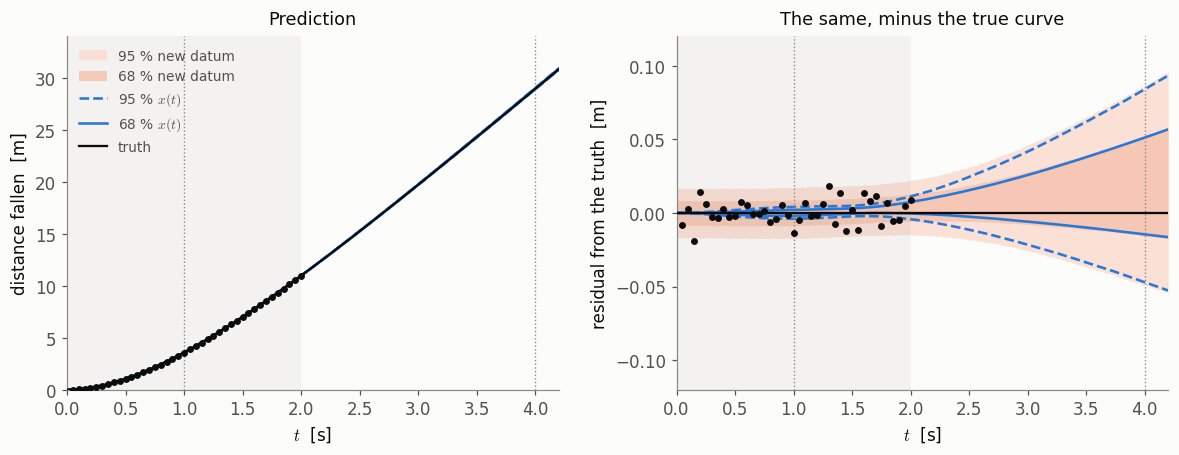

In [10]:
r = np.random.default_rng(32)
curves = distance(tg[None, :], chain[:, [0]], chain[:, [1]])
data_draws = curves + r.normal(0, 1, curves.shape) * chain[:, [2]]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4),
                         gridspec_kw=dict(wspace=0.24, left=0.07, right=0.98,
                                          top=0.87, bottom=0.14))
for ax, resid in zip(axes, (False, True)):
    ref = distance(tg, G_TRUE, TAU_TRUE) if resid else 0.0
    for lo, hi, col, lab in ((2.5, 97.5, FILL2, "95 % new datum"),
                             (16, 84, "#f5c3ae", "68 % new datum")):
        q = np.percentile(data_draws, [lo, hi], axis=0)
        ax.fill_between(tg, q[0] - ref, q[1] - ref, color=col, lw=0, alpha=0.85,
                        label=lab)
    for lo, hi, ls, lab in ((2.5, 97.5, "dashed", r"95 % $x(t)$"),
                            (16, 84, "solid", r"68 % $x(t)$")):
        q = np.percentile(curves, [lo, hi], axis=0)
        ax.plot(tg, q[0] - ref, color=C1, lw=1.7, ls=ls, label=lab)
        ax.plot(tg, q[1] - ref, color=C1, lw=1.7, ls=ls)
    ax.plot(tg, distance(tg, G_TRUE, TAU_TRUE) - ref, color=INK, lw=1.5,
            label="truth", zorder=6)
    ax.axvspan(0, T_OBS, color=INK_MUTED, alpha=0.08, lw=0)
    for ts in (T_IN, T_OUT):
        ax.axvline(ts, color=INK_MUTED, lw=0.9, ls=":")
    ax.set_xlabel("$t$  [s]")
    ax.set_xlim(0, tg[-1])
axes[0].plot(t_data, x_data, "o", ms=3.5, color=INK, zorder=7)
axes[0].set_ylabel("distance fallen  [m]")
axes[0].set_ylim(0, 34)
axes[0].legend(frameon=False, fontsize=9, labelcolor=INK_SOFT, loc="upper left")
axes[0].set_title("Prediction", fontsize=11.5, pad=8)
axes[1].plot(t_data, x_data - distance(t_data, G_TRUE, TAU_TRUE), "o", ms=3.5,
             color=INK, zorder=7)
axes[1].set_ylabel("residual from the truth  [m]")
axes[1].set_ylim(-0.12, 0.12)
axes[1].set_title("The same, minus the true curve", fontsize=11.5, pad=8)
plt.show()

The right panel is the one worth looking at: on the scale of the prediction itself
the bands are invisible, so we subtract the true curve.

Two observations, both the same as in the linear-regression demo:

- the band **widens outside the window** — the $68\%$ interval on $x(t)$ grows from
  $\pm 0.2$ cm at $t^\odot=1$ s to $\pm 3.3$ cm at $t^\odot = 4$ s, a factor $16$;
- and **which uncertainty dominates flips**: inside, a new measurement is limited by
  $\sigma_\epsilon = 1$ cm; outside, parameter uncertainty has overtaken it and the two
  bands merge.

But there is a difference from the polynomial, and it is the point of using a
physics model. The extrapolated prediction is still good to $0.11\%$ — the
functional form knows that the motion becomes uniform at $v_t$, so extrapolation
costs precision rather than destroying it. A quadratic fitted to the same data would
be free to curve anywhere once the data run out.

## 6. How much of that is Monte Carlo noise?

Repeat the sampling with different seeds and shorter chains. The posterior does not
move; our estimate of it does.

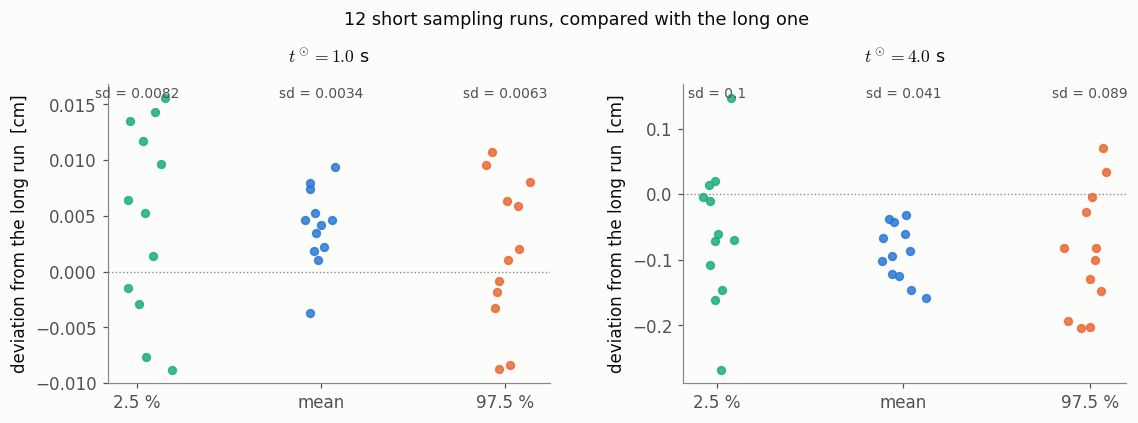

In [11]:
N_REPEAT = 12
reps = []
for seed in range(N_REPEAT):
    ch, _ = run_mcmc(t_data, x_data, nsteps=3000, nburn=1000, thin=5, seed=200 + seed)
    rr = np.random.default_rng(700 + seed)
    reps.append({ts: summarise(predict(ch, ts, rr)) for ts in (T_IN, T_OUT)})

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0),
                         gridspec_kw=dict(wspace=0.3, left=0.09, right=0.98,
                                          top=0.82, bottom=0.14))
ref = {ts: summarise(predict(chain, ts, np.random.default_rng(99))) for ts in (T_IN, T_OUT)}
for ax, ts in zip(axes, (T_IN, T_OUT)):
    for k, (key, col) in enumerate([("q025", C3), ("mean", C1), ("q975", C2)]):
        vals = 100 * (np.array([rep[ts][key] for rep in reps]) - ref[ts][key])  # cm
        ax.scatter(np.full(N_REPEAT, k) + rng.normal(0, 0.06, N_REPEAT), vals,
                   s=26, color=col, alpha=0.85, zorder=3)
        ax.text(k, 0.99, f"sd = {vals.std():.2g}", fontsize=9, color=INK_SOFT,
                ha="center", va="top", transform=ax.get_xaxis_transform())
    ax.axhline(0, color=INK_MUTED, lw=0.9, ls=":")
    ax.set_xticks([0, 1, 2], ["2.5 %", "mean", "97.5 %"])
    ax.set_ylabel("deviation from the long run  [cm]")
    ax.set_title(fr"$t^\odot = {ts}$ s", fontsize=11.5, pad=14)
fig.text(0.5, 0.955, "12 short sampling runs, compared with the long one",
         ha="center", fontsize=11.5, color=INK)
plt.show()

The scatter is Monte Carlo error. As before, the tail quantiles are the noisy
estimators — they are set by the few percent of samples furthest out, so they need
the most chain to pin down. Quote intervals only to the precision the chain supports.

## 7. Model checking

### The model as specified

Replicate data sets at the observed $t_i$, drawn from the posterior predictive, next
to the real data.

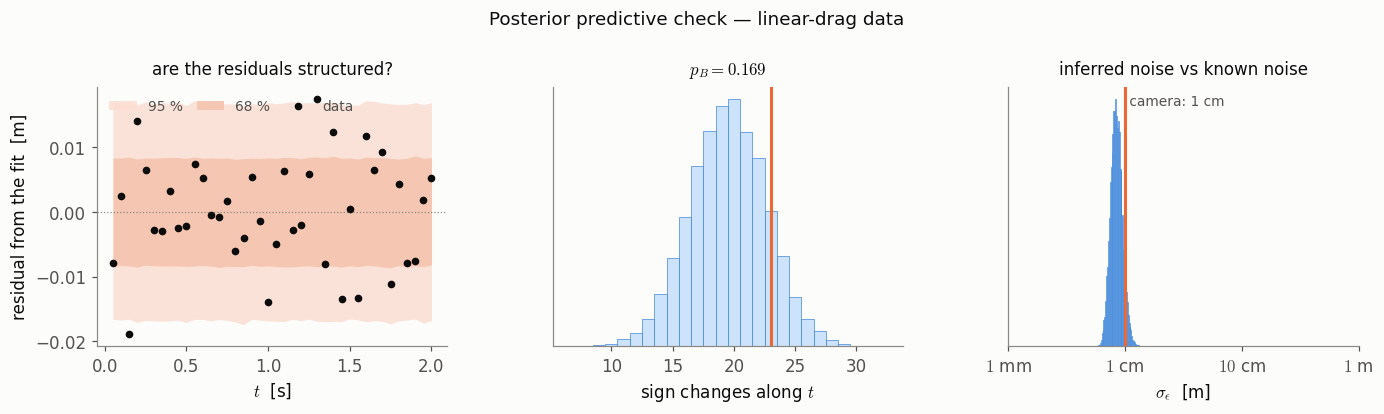

  sign changes: observed 23, replicates 20 (p_B = 0.169);   sigma_eps = 0.8 cm vs the known 1 cm


In [12]:
def ppc_figure(chain, t, x, title, seed=41):
    r = np.random.default_rng(seed)
    mu = distance(t[None, :], chain[:, [0]], chain[:, [1]])   # one curve per sample
    rep = mu + r.normal(0, 1, mu.shape) * chain[:, [2]]       # replicate data sets
    resid_obs = x[None, :] - mu                               # data, model subtracted
    resid_rep = rep - mu                                      # replicates, likewise

    fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.8),
                             gridspec_kw=dict(wspace=0.3, left=0.06, right=0.985,
                                              top=0.80, bottom=0.18))
    q = np.percentile(resid_rep, [2.5, 16, 84, 97.5], axis=0)
    axes[0].fill_between(t, q[0], q[3], color=FILL2, alpha=0.8, lw=0, label="95 %")
    axes[0].fill_between(t, q[1], q[2], color="#f5c3ae", alpha=0.9, lw=0, label="68 %")
    axes[0].plot(t, np.median(resid_obs, axis=0), "o", ms=4, color=INK, zorder=4,
                 label="data")
    axes[0].axhline(0, color=INK_MUTED, lw=0.8, ls=":")
    axes[0].set_xlabel("$t$  [s]")
    axes[0].set_ylabel("residual from the fit  [m]")
    axes[0].legend(frameon=False, fontsize=9, labelcolor=INK_SOFT, loc="upper left",
                   ncol=3, columnspacing=1.0)
    axes[0].set_title("are the residuals structured?", fontsize=11, pad=8)

    # a statistic blind to the SIZE of the residuals, sensitive only to their ORDER
    T = lambda R: np.sum(np.diff(np.sign(R), axis=1) != 0, axis=1)
    t_rep, t_obs = T(resid_rep), np.median(T(resid_obs))
    p = np.mean(t_rep >= t_obs)
    axes[1].hist(t_rep, bins=np.arange(t_rep.min() - 0.5, t_rep.max() + 1.5),
                 color=FILL1, edgecolor=C1, lw=0.4)
    axes[1].axvline(t_obs, color=C2, lw=2)
    axes[1].set_xlabel("sign changes along $t$")
    axes[1].set_yticks([])
    axes[1].set_title(f"$p_B = {p:.3f}$", fontsize=11, pad=8)

    # the inferred noise level against the one the instrument actually has
    axes[2].hist(np.log10(chain[:, 2]), bins=50, color=FILL1, edgecolor=C1, lw=0.4)
    axes[2].axvline(np.log10(SIGMA_TRUE), color=C2, lw=2)
    axes[2].text(np.log10(SIGMA_TRUE), 0.97, " camera: 1 cm ", fontsize=9,
                 color=INK_SOFT, ha="left", va="top",
                 transform=axes[2].get_xaxis_transform())
    axes[2].set_xlabel(r"$\sigma_\epsilon$  [m]")
    axes[2].set_xticks([-3, -2, -1, 0], ["$1$ mm", "$1$ cm", "$10$ cm", "$1$ m"])
    axes[2].set_yticks([])
    axes[2].set_title(r"inferred noise vs known noise", fontsize=11, pad=8)
    fig.text(0.5, 0.95, title, ha="center", fontsize=12, color=INK)
    plt.show()
    print(f"  sign changes: observed {t_obs:.0f}, replicates {np.median(t_rep):.0f} "
          f"(p_B = {p:.3f});   sigma_eps = {chain[:, 2].mean() * 100:.1f} cm "
          f"vs the known {SIGMA_TRUE * 100:.0f} cm")


ppc_figure(chain, t_data, x_data, "Posterior predictive check — linear-drag data")

Both statistics land in the bulk. The second one — how often the residuals change
sign along $t$ — is chosen deliberately: it is blind to the *size* of the residuals
and sensitive only to whether they are **structured in time**, which is exactly how
a wrong functional form fails.

### Now break the model

As flagged at the outset, real drag on a ball at these Reynolds numbers is
quadratic, not linear. Generate the
data from $m\dot v = mg - c v^2$ (same terminal velocity) and fit the linear-drag
model anyway. Nothing else changes.

In [13]:
def distance_quadratic(t, g, vt):
    "Distance fallen from rest with quadratic drag, same terminal velocity."
    tau = vt / g
    return vt * tau * np.log(np.cosh(np.asarray(t, float) / tau))


x_quad = distance_quadratic(t_data, G_TRUE, VT_TRUE) + \
    np.random.default_rng(77).normal(0, SIGMA_TRUE, ND)

chain_q, _ = run_mcmc(t_data, x_quad, seed=7)
vt_q = chain_q[:, 0] * chain_q[:, 1]
print("fitting the LINEAR-drag model to QUADRATIC-drag data:")
for nm, v, truth in (("g    ", chain_q[:, 0], G_TRUE), ("tau  ", chain_q[:, 1], TAU_TRUE),
                     ("sigma", chain_q[:, 2], SIGMA_TRUE), ("v_t  ", vt_q, VT_TRUE)):
    print(f"  {nm} {v.mean():8.4f} +- {v.std():7.4f}   (true {truth:.4f})   "
          f"{'<-- ' + f'{abs(v.mean() - truth) / v.std():.0f} sigma off' if abs(v.mean() - truth) > 3 * v.std() else ''}")

fitting the LINEAR-drag model to QUADRATIC-drag data:
  g      11.7178 +-  0.0840   (true 9.8100)   <-- 23 sigma off
  tau     0.9310 +-  0.0152   (true 0.9684)   
  sigma   0.0428 +-  0.0050   (true 0.0100)   <-- 7 sigma off
  v_t    10.9075 +-  0.1018   (true 9.5000)   <-- 14 sigma off


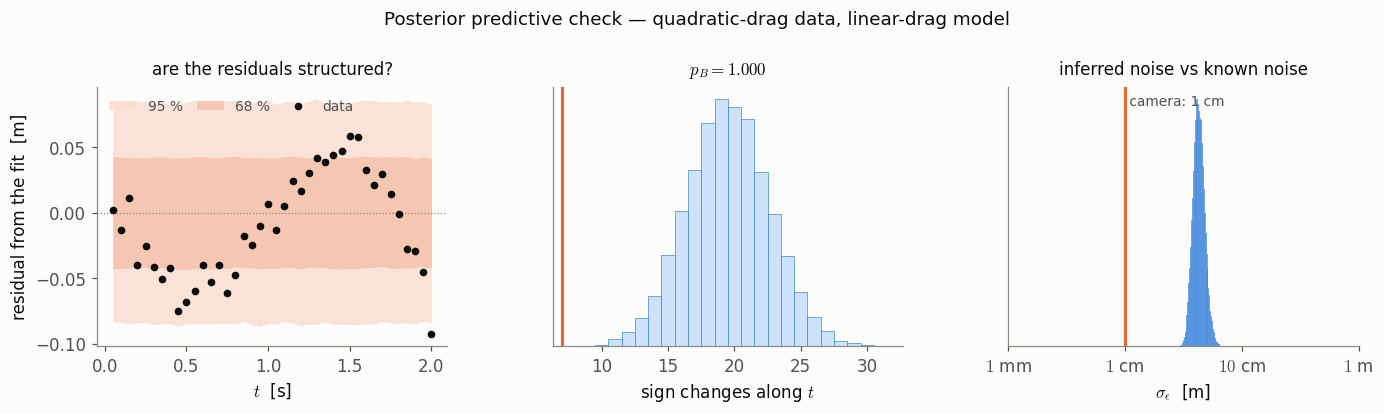

  sign changes: observed 7, replicates 19 (p_B = 1.000);   sigma_eps = 4.3 cm vs the known 1 cm


In [14]:
ppc_figure(chain_q, t_data, x_quad,
           "Posterior predictive check — quadratic-drag data, linear-drag model",
           seed=43)

Three signatures, each saying something different.

**The residuals are structured.** They trace a smooth arc instead of scattering, and
the sign-change statistic — deliberately blind to the *size* of the residuals —
collapses from about 19 to 7. This is the check that works.

**The inferred noise is not the instrument's noise.** The fit reports
$\sigma_\epsilon \approx 4$ cm where the camera is good to 1 cm. Faced with a systematic
trend it cannot describe, the model's only escape is to call the trend noise. An
inferred error that disagrees with the measured one is itself a misfit diagnostic,
and here it is a factor of four.

**And the parameters are catastrophically wrong.** $g = 11.72 \pm 0.08$ m/s$^2$ and
$v_t = 10.91 \pm 0.10$ m/s, against truths of $9.81$ and $9.5$ — that is $23$ and
$14$ standard deviations. Inflating $\sigma_\epsilon$ widened the error bars fourfold and
it was *nowhere near enough*: the systematic trend pulls the parameters far harder
than it loosens them. This is the failure mode to be afraid of, because the result
looks precise.

Note what this means for the obvious test: a $\chi^2$ statistic has little power
here, because $\sigma_\epsilon$ is a free parameter that absorbs exactly what $\chi^2$
would have measured — the fit simply reports a larger noise and a fine $\chi^2$.
**When the noise scale is inferred, test the shape of the residuals, not their size.**

This is precisely the situation the discrepancy models of Part II are built for.

> **Follow-up**
>
> 1. *Refit the misspecified case using only $t < 0.5$ s. Does the check still fail,
>    and what has happened to the error bar on $g$?*
> 2. *Add a discrepancy term $\delta(t)$ with a simple functional form and refit. Can
>    you recover an unbiased $g$ at the cost of a larger uncertainty?*

---